this notebook contains the cell-cell communication analysis shown in Figure 4 F-H, Supplementary Figure S6 B-C,Supplementary Figure S7 A-D

# Load packages and helper functins

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
plot_folder ="/media/synology/Rahel/BOS paper/Public Dataset/Cell chat/Analysis/Results/"

In [3]:
import rpy2.robjects as ro

In [4]:
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore")
from rpy2.robjects import pandas2ri
#pandas2ri.activate()
%load_ext rpy2.ipython




In [5]:
%%R
R.version

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          3.3                         
year           2024                        
month          02                          
day            29                          
svn rev        86002                       
language       R                           
version.string R version 4.3.3 (2024-02-29)
nickname       Angel Food Cake             


In [6]:
%%R
library(CellChat)
library(patchwork)
library(anndata)
library(NMF)
library(ggalluvial)
options(stringsAsFactors = FALSE)
library(reticulate)
#reticulate::py_install(packages = 'umap-learn')

R[write to console]: Loading required package: dplyr

R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: Loading required package: igraph

R[write to console]: 
Attaching package: ‘igraph’


R[write to console]: The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


R[write to console]: The following objects are masked from ‘package:stats’:

    decompose, spectrum


R[write to console]: The following object is masked from ‘package:base’:

    union


R[write to console]: Loading required package: ggplot2




    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

R[write to console]: Loading required package: registry

R[write to console]: Loading required package: rngtools

R[write to console]: Loading required package: cluster

R[write to console]: NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

R[write to console]:   To enable shared memory capabilities, try: install.extras('
NMF
')

R[write to console]: 
Attaching package: ‘NMF’


R[write to console]: The following objects are masked from ‘package:igraph’:

    algorithm, compare




In [7]:
%%R
packageVersion("CellChat")

[1] ‘2.2.0’


## Load data

In [8]:
%%R
ad <- read_h5ad("/media/synology/4i/4i_FibFoci/TMA_qupath_seg/TMA_BT02/TMA_BT02_annotated/BT02_vs_BT01_control/public_dataset_BOS/260126_public_dataset_BOS_detailed_annotation_.h5ad")
#access normalized expression matrix (genes x cells)
data.input <- t(py_to_r(ad$X)) 
rownames(data.input) <- rownames(py_to_r(ad$var)) 
colnames(data.input) <- rownames(py_to_r(ad$obs)) 
#access meta data (columns)  
meta <- py_to_r(ad$obs)
table(meta$severity)

R[write to console]: 



+ . /home/rahelb/miniconda3/bin/activate
+ conda activate '/home/rahelb/miniconda3/envs/r_env'
+ '/home/rahelb/miniconda3/envs/r_env/bin/python' -m pip install --upgrade --no-user anndata


R[write to console]: Done!



< table of extent 0 >


In [9]:
%%R
meta$Level_4i <- as.character(meta$Level_4i)

table(meta$Level_4i, useNA = "ifany")


Airway epithelial cells           AT1/AT2 cells                 B cells 
                   5853                   26566                     547 
            Basal cells             Capillaries         Dendritic cells 
                    263                   13186                    1382 
            Fibroblasts            Lymphatic EC             Macrophages 
                   4220                     834                   28987 
             Mast cells             Mesothelial               Monocytes 
                   2204                      55                   28363 
               NK cells   Pan-Endothelial cells                Pericyte 
                   2872                    5629                    3101 
           Plasma cells         PLVAP+ VWA1+ EC                    SMCs 
                     34                    1756                    1442 
                T cells 
                  22470 


In [10]:
%%R
table(meta$meta_2)

< table of extent 0 >


In [11]:
%%R
unique(meta$Level_4i)

 [1] "AT1/AT2 cells"           "Capillaries"            
 [3] "Airway epithelial cells" "Fibroblasts"            
 [5] "Lymphatic EC"            "Pericyte"               
 [7] "SMCs"                    "Pan-Endothelial cells"  
 [9] "PLVAP+ VWA1+ EC"         "Basal cells"            
[11] "Mesothelial"             "Monocytes"              
[13] "Dendritic cells"         "NK cells"               
[15] "Macrophages"             "B cells"                
[17] "T cells"                 "Mast cells"             
[19] "Plasma cells"           


In [12]:
%%R
celltypes_of_interest <- c('AT1/AT2 cells',
'Capillaries',
'Airway epithelial cells',
'Fibroblasts',
 'Lymphatic EC',
 'Pericyte',
 'SMCs',
 'Pan-Endothelial cells',
 'PLVAP+ VWA1+ EC',
 'Basal cells',
  'Monocytes',
 'Dendritic cells',
 'NK cells',
 'Macrophages',
 'B cells',
 'T cells',
 'Mast cells',
 'Plasma cells')

meta <- meta %>% filter(Level_4i %in% celltypes_of_interest)
data.input <- data.input[, rownames(meta)]

In [13]:
%%R
meta_BOS <- meta[meta$condition2 == "BOS",]
# Subset expression matrix accordingly
data_BOS <- data.input[, rownames(meta_BOS)]

In [14]:
%%R
meta_control <- meta[meta$condition2== "Control",]
data_control <- data.input[, rownames(meta_control)]

In [15]:
%%R
cellchat_BOS <- createCellChat(object = data_BOS, meta = meta_BOS, group.by = "Level_4i")
cellchat_control   <- createCellChat(object = data_control, meta = meta_control, group.by = "Level_4i")
# Put into a list
object.list <- list(control = cellchat_control, BOS = cellchat_BOS)
names(object.list)

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Airway epithelial cells, AT1/AT2 cells, B cells, Basal cells, Capillaries, Dendritic cells, Fibroblasts, Lymphatic EC, Macrophages, Mast cells, Monocytes, NK cells, Pan-Endothelial cells, Pericyte, Plasma cells, PLVAP+ VWA1+ EC, SMCs, T cells 
[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Airway epithelial cells, AT1/AT2 cells, B cells, Basal cells, Capillaries, Dendritic cells, Fibroblasts, Lymphatic EC, Macrophages, Mast cells, Monocytes, NK cells, Pan-Endothelial cells, Pericyte, Plasma cells, PLVAP+ VWA1+ EC, SMCs, T cells 
[1] "control" "BOS"    


In [16]:
%%R
CellChatDB <- CellChatDB.human  # or CellChatDB.mouse depending on your data
showDatabaseCategory(CellChatDB)
# Show the structure of the database
#dplyr::glimpse(CellChatDB$interaction)

# use all CellChatDB except for "Non-protein Signaling" for cell-cell communication analysis
CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling", key = "annotation") # use Secreted Signaling
#CellChatDB.use <- subsetDB(CellChatDB) # exclude non-protein signaling

In [17]:
%%R
for (i in 1:length(object.list)) {
  object.list[[i]]@DB <- CellChatDB.use  # assign database
  object.list[[i]] <- addMeta(object.list[[i]], meta = object.list[[i]]@meta)
  object.list[[i]] <- setIdent(object.list[[i]], ident.use = "Level_4i")   # cell groups
  object.list[[i]] <- subsetData(object.list[[i]])
  object.list[[i]] <- identifyOverExpressedGenes(object.list[[i]])
  object.list[[i]] <- identifyOverExpressedInteractions(object.list[[i]])
  object.list[[i]] <- computeCommunProb(object.list[[i]])
  object.list[[i]] <- filterCommunication(object.list[[i]], min.cells = 10)
  object.list[[i]] <- computeCommunProbPathway(object.list[[i]])
  object.list[[i]] <- aggregateNet(object.list[[i]])
}

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
The number of highly variable ligand-receptor pairs used for signaling inference is 874 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-04-02 15:15:46.359302]"


  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |                                                                      |   1%
  |                                                                            
  |=                                                                     |   1%
  |                                                                            
  |=                                                                     |   2%
  |                                                                            
  |==                                                                    |   2%
  |                                                                            
  |==                                                                    |   3%
  |                                     

[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-04-02 15:21:38.214385]"
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
The number of highly variable ligand-receptor pairs used for signaling inference is 948 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-04-02 15:21:50.67688]"


  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |                                                                      |   1%
  |                                                                            
  |=                                                                     |   1%
  |                                                                            
  |=                                                                     |   2%
  |                                                                            
  |==                                                                    |   2%
  |                                                                            
  |==                                                                    |   3%
  |                                     

[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-04-02 15:30:03.750846]"


In [18]:
%%R
cellchat <- mergeCellChat(object.list, add.names = names(object.list))

R[write to console]: Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [19]:
%%R -i plot_folder -w 500 -h 200
gg1 <- compareInteractions(cellchat, show.legend = FALSE, group = c(1,2))

# Compare interaction strength
gg2 <- compareInteractions(cellchat, show.legend = FALSE, group = c(1,2), measure = "weight")

gg1 + gg2

ggsave(file.path(plot_folder, "interaction_number.pdf"), gg1, width = 5, height = 4)
ggsave(file.path(plot_folder, "interaction_weight.pdf"), gg2, width = 5, height = 4)

## Identify dysfunctional signaling by comparing the communication probabities

In [21]:
%%R
levels(cellchat@idents$joint)     # check cell types

 [1] "Airway epithelial cells" "AT1/AT2 cells"          
 [3] "B cells"                 "Basal cells"            
 [5] "Capillaries"             "Dendritic cells"        
 [7] "Fibroblasts"             "Lymphatic EC"           
 [9] "Macrophages"             "Mast cells"             
[11] "Monocytes"               "NK cells"               
[13] "Pan-Endothelial cells"   "Pericyte"               
[15] "Plasma cells"            "PLVAP+ VWA1+ EC"        
[17] "SMCs"                    "T cells"                


In [22]:
%%R
levels(cellchat@idents$joint)     # check cell types
levels(cellchat@meta$datasets)    # should show "Stable" and "Progressive"

[1] "control" "BOS"    


R[write to console]: Comparing communications on a merged object 


R[write to console]: Comparing communications on a merged object 




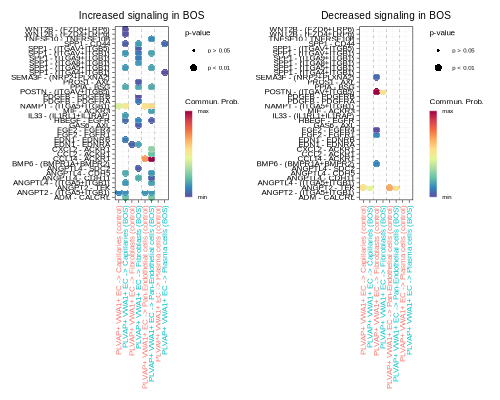

In [24]:
%%R -i plot_folder -w 500 -h 400

#pdf(file.path(plot_folder, "differential_signaling_all.pdf"), width = 8, height = 7)
b1 <- netVisual_bubble(cellchat, sources.use = "PLVAP+ VWA1+ EC", targets.use = c("Pan-Endothelial cells", "Capillaries","Fibroblasts","Plasma cells"),  comparison = c(1, 2), max.dataset = 2, title.name = "Increased signaling in BOS", angle.x = 90, remove.isolate = F)
b2 <- netVisual_bubble(cellchat, sources.use = "PLVAP+ VWA1+ EC", targets.use = c("Pan-Endothelial cells", "Capillaries","Fibroblasts","Plasma cells"),  comparison = c(1, 2), max.dataset = 1, title.name = "Decreased signaling in BOS", angle.x = 90, remove.isolate = F)
b1+b2

R[write to console]: Comparing communications on a merged object 


R[write to console]: Comparing communications on a merged object 




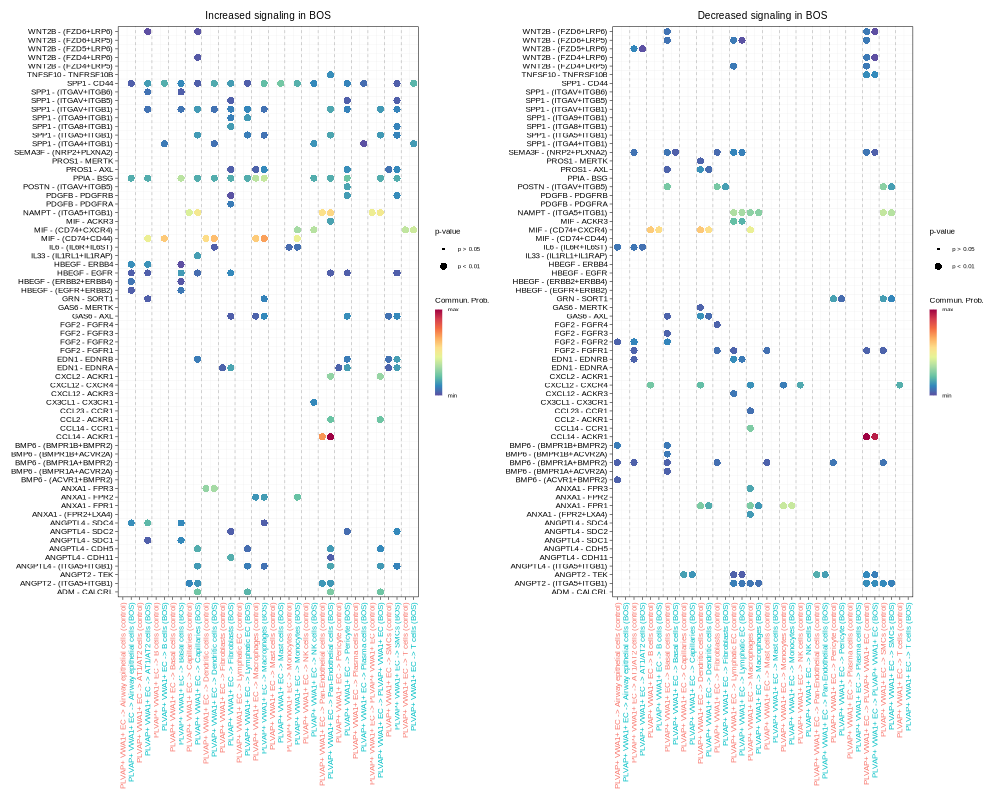

In [25]:
%%R -i plot_folder -w 1000 -h 800
#pdf(file.path(plot_folder, "differential_signaling_all_out.pdf"), width = 20, height = 15)
b1 <- netVisual_bubble(cellchat, sources.use = "PLVAP+ VWA1+ EC", targets.use = NULL,  comparison = c(1, 2), max.dataset = 2, title.name = "Increased signaling in BOS", angle.x = 90, remove.isolate = F)
b2 <- netVisual_bubble(cellchat, sources.use = "PLVAP+ VWA1+ EC", targets.use = NULL,  comparison = c(1, 2), max.dataset = 1, title.name = "Decreased signaling in BOS", angle.x = 90, remove.isolate = F)
b1+b2

R[write to console]: Comparing communications on a merged object 


R[write to console]: Comparing communications on a merged object 




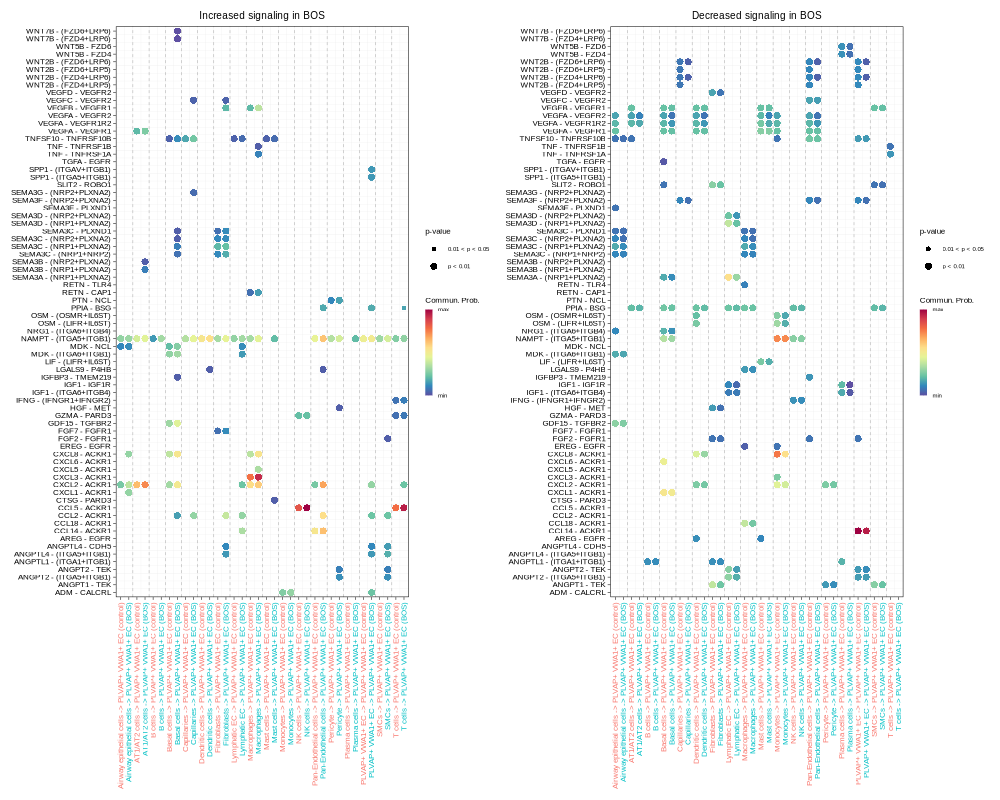

In [26]:
%%R -i plot_folder -w 1000 -h 800
#pdf(file.path(plot_folder, "differential_signaling_all_in.pdf"), width = 20, height = 15)
b1 <- netVisual_bubble(cellchat, sources.use = NULL, targets.use = "PLVAP+ VWA1+ EC",  comparison = c(1, 2), max.dataset = 2, title.name = "Increased signaling in BOS", angle.x = 90, remove.isolate = F)
b2 <- netVisual_bubble(cellchat, sources.use = NULL, targets.use = "PLVAP+ VWA1+ EC",  comparison = c(1, 2), max.dataset = 1, title.name = "Decreased signaling in BOS", angle.x = 90, remove.isolate = F)
b1+b2

# Harmonization of Colores with 4i

In [27]:
%%R
cellchat@idents <- factor(cellchat@meta$Level_4i)

In [28]:
%%R
levels(cellchat@idents)

 [1] "Airway epithelial cells" "AT1/AT2 cells"          
 [3] "B cells"                 "Basal cells"            
 [5] "Capillaries"             "Dendritic cells"        
 [7] "Fibroblasts"             "Lymphatic EC"           
 [9] "Macrophages"             "Mast cells"             
[11] "Monocytes"               "NK cells"               
[13] "Pan-Endothelial cells"   "Pericyte"               
[15] "Plasma cells"            "PLVAP+ VWA1+ EC"        
[17] "SMCs"                    "T cells"                


In [29]:
%%R
new_colors <- c(
 "Airway epithelial cells" = "#79b8e8",
  "AT1/AT2 cells" = "#135fae",
  "B cells" = "#86d960",
  "Basal cells" = "#22841f",
  "Capillaries" = "#f96869",
  "Dendritic cells" = "#4cc9f0",
  "Fibroblasts" = "#c70e15",
  "Lymphatic EC" = "#ffb244",
  "Macrophages" = "#ff6700",
  "Mast cells" = "#e6399b",
  "Monocytes" = "#a6761d",
  "NK cells" = "#6a4c93",
  "Pan-Endothelial cells" = "#b089d6",
  "Pericyte" = "#7f7f7f",
  "Plasma cells" = "#56278d",
  "PLVAP+ VWA1+ EC" = "#c51b7d",
  "SMCs" = "#fff066",
  "T cells" = "#8f3f15"
)

In [30]:
%%R
cellchat@net$color.use <- new_colors

## Compare the number of interactions and interaction strength among different cell populations

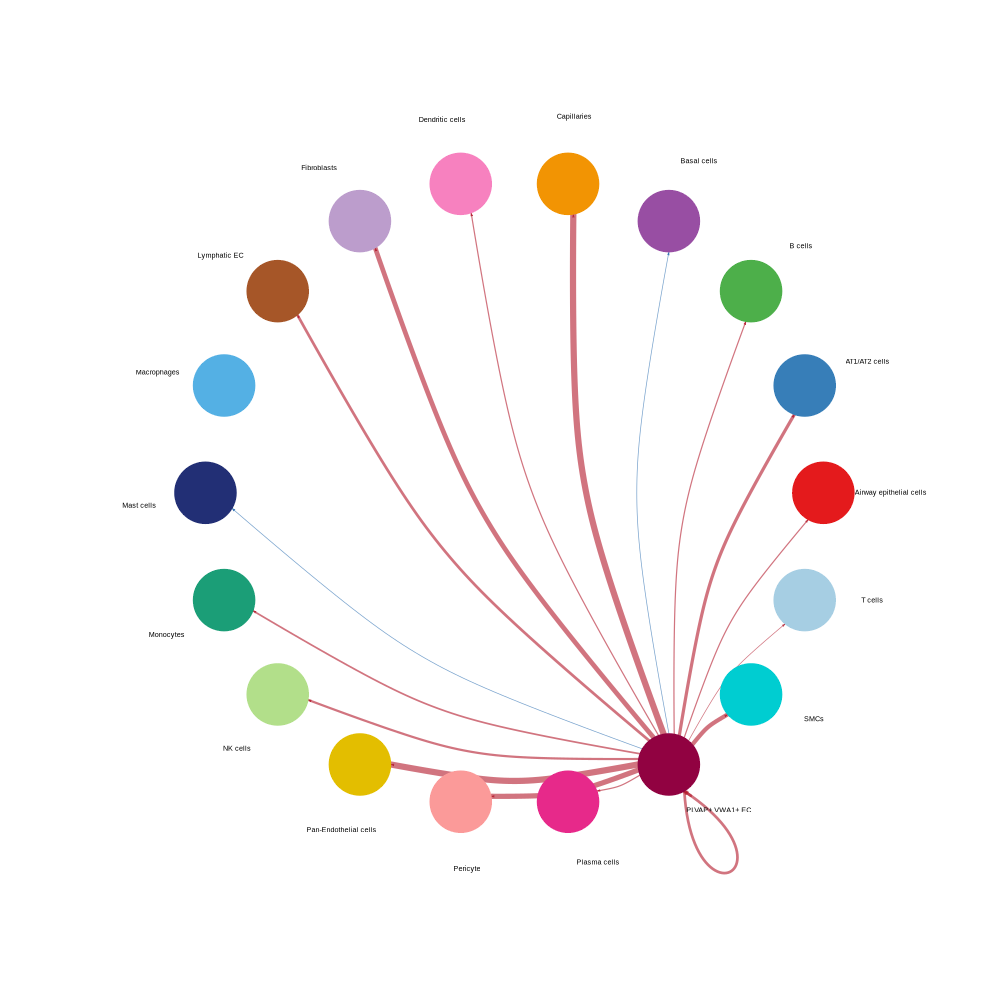

In [33]:
%%R -i plot_folder -w 1000 -h 1000
#pdf(file.path(plot_folder, "differential_nr_interactions_plvap.pdf"), width = 6, height = 6) 
netVisual_diffInteraction(cellchat, 
                          weight.scale = TRUE,
                          sources.use = "PLVAP+ VWA1+ EC",#color.use = new_colors,
                          vertex.label.cex = 0.6)



R[write to console]: Do heatmap based on a merged object 


R[write to console]: Do heatmap based on a merged object 




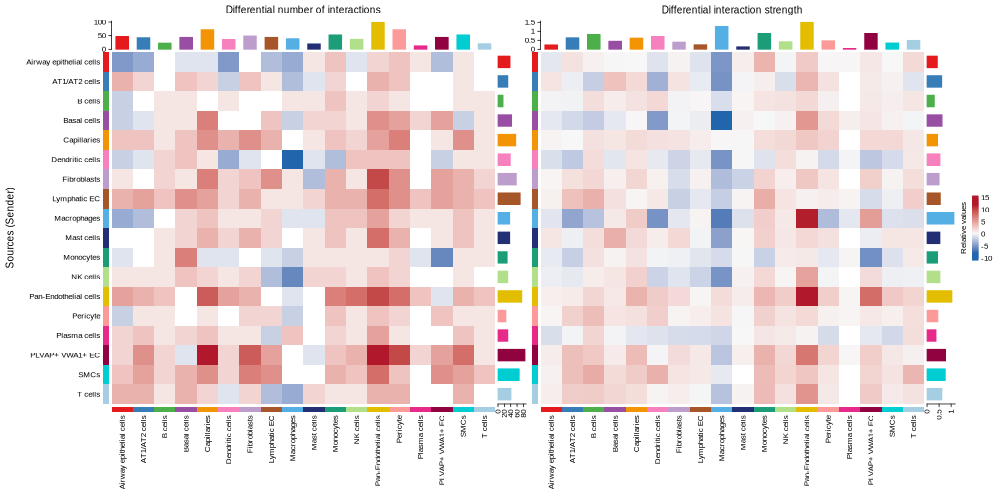

In [35]:
%%R -i plot_folder -w 1000 -h 500
# Heatmap showing differential number of interactions or interaction strength among different cell populations across two datasets
#pdf(file.path(plot_folder, "differential_interaction_heat.pdf"), width = 12, height = 6)
h1 <- netVisual_heatmap(cellchat)
h2 <- netVisual_heatmap(cellchat, measure = "weight")
h1+h2



## Compare the major sources and targets in a 2D space

R[write to console]: 
Attaching package: ‘future’


R[write to console]: The following object is masked from ‘package:NMF’:

    run


R[write to console]: The following objects are masked from ‘package:igraph’:

    %->%, %<-%




  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01s  


R[write to console]: Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

R[write to console]: Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways



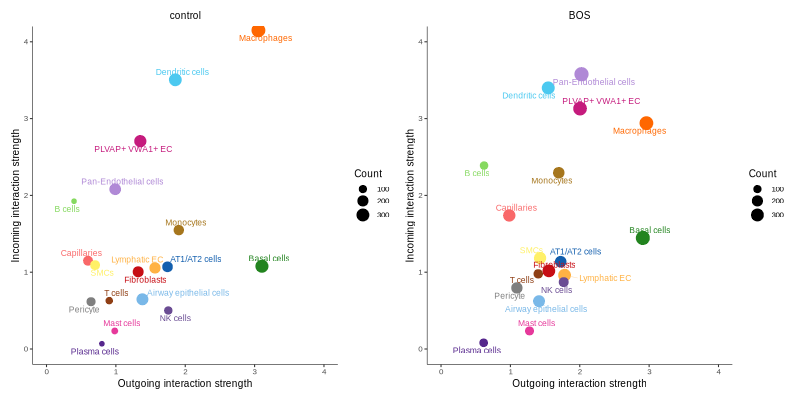

In [36]:
%%R -i plot_folder -w 800 -h 400
#pdf(file.path(plot_folder, "major_sources_targets_1.pdf"), width = 12, height = 6)
library(future)
plan(sequential)
for (i in 1:length(object.list)) {
  object.list[[i]] <- netAnalysis_computeCentrality(object.list[[i]], slot.name = "netP")
}
gg <- list()
num.link <- sapply(object.list, function(x) {rowSums(x@net$count) + colSums(x@net$count) - diag(x@net$count)})
weight.MinMax <- c(min(num.link), max(num.link))

for (i in 1:length(object.list)) {
  gg[[i]] <- netAnalysis_signalingRole_scatter(object.list[[i]],title = names(object.list)[i],weight.MinMax = weight.MinMax,color.use = new_colors) +
              coord_cartesian(xlim = c(0, 4), ylim = c(0, 4))
}

 

wrap_plots(plots = gg)